This notebook shows the Prospector fits in some more detail; specifically it plots
* the best-fit SED
* SFH
* posteriors 


--
Bingjie Wang; bwang@psu.edu

In [1]:
import numpy as np
import corner
import matplotlib.pyplot as plt
from matplotlib import gridspec
from matplotlib.ticker import FormatStrFormatter

In [2]:
from astropy.table import Table
import h5py

# Data files

In most cases, there is no need to interact with them.

In [3]:
# fver = 'v3.0.2_LW_SUPER_spsv2.0' # DR2
base = '/Users/wren/Projects/minerva/test_postprocess/' #'/Volumes/DarkPhoenix/Surveys/UNCOVER/sed_catalogs/v5.3.0/'
# fver = 'v5.3.0_LW_SUPER_spsv1.0'
# ffsed = 'seds_map_{}.npz'.format(fver)
# ffsfh = 'ancillaries/sfhs_{}.npz'.format(fver)
# ffchain = 'chains_{}.npz'.format(fver)

# load data
fsed = h5py.File(base+'spec_phisfh.h5', 'r')
fsfh = h5py.File(base+'sfh_phisfh.h5', 'r')
fchain = h5py.File(base+'chains_phisfh.h5', 'r')

In [4]:
list(fsed.keys())

['chi2_fsps',
 'modmag_map',
 'modspec_map',
 'nbands',
 'objid',
 'obsmag',
 'obsmag_unc',
 'wavspec',
 'weff',
 'zred']

In [5]:
for key in fsed.keys():
    print(key, fsed[key].shape)

chi2_fsps (660,)
modmag_map (660, 28)
modspec_map (660, 5994)
nbands (660,)
objid (660,)
obsmag (660, 28)
obsmag_unc (660, 28)
wavspec (5994,)
weff (28,)
zred (660,)


In [6]:
for key in fsfh.keys():
    print(key, fsfh[key].shape)

agebins_max (660,)
objid (660,)
percentiles (7,)
sfh (660, 7, 100)


In [7]:
for key in fchain.keys():
    print(key, fchain[key].shape)

chains (660, 1001, 26)
objid (660,)
theta_labels (26,)


# Useful functions

## Maximum-likelihood spectrum

In the cases where the median of the redshift posterior is significantly different from the maximum-likelihood redshift, there is a disconnection between the best-fit SED and the inferred redshift/parameters. If you need to plot SEDs for those cases, let me know.

In [9]:
def plot_sed(objid, plt_jy=True, sdir=None):
    
    if objid not in fsed['objid']:
        print('no sed for obj {}; likely use_phot=0'.format(objid))
        return None
    
    _idx = np.squeeze(np.where(fsed['objid'][:]==objid))

    fig = plt.figure(figsize=(5.5,5))
    gs = gridspec.GridSpec(2,1, height_ratios=[3,1])
    gs.update(hspace=0)
    phot, resid = plt.Subplot(fig, gs[0]), plt.Subplot(fig, gs[1])
    fig.add_subplot(phot)
    fig.add_subplot(resid)
    
    # use the max-likelihood zred to shift the spectrum
    zred = fsed['zred'][_idx]
    print('zml:', zred)
    obsmags = fsed['obsmag'][_idx]
    obsunc = fsed['obsmag_unc'][_idx]
    wavspec = fsed['wavspec'][:] * (1+zred)
    
    weff = fsed['weff'][:] / 1e4
    wavspec = wavspec / 1e4
    
    modmags = fsed['modmag_map'][_idx]
    modspec = fsed['modspec_map'][_idx]
    
    mask = np.isfinite(obsmags)
    obsmags = obsmags[mask]
    obsunc = obsunc[mask]
    weff = weff[mask]
    modmags = modmags[mask]
    obsunc = np.clip(obsunc, a_min=obsmags*0.05, a_max=None)
        
    if plt_jy:
        obsmags *= 3631
        obsunc *= 3631
        modmags *= 3631
        modspec *= 3631

    phot.errorbar(weff, modmags, fmt='o', color='firebrick', label='model photometry', zorder=100,
                  elinewidth=1, mec='k', mew=0.2)

    phot.errorbar(weff, obsmags, yerr=obsunc, color='black', fmt='o', label='observed photometry', zorder=101)
    phot.plot(wavspec, modspec, '-', color='firebrick', label = 'model spectrum', zorder=-100)
    
    # ignore alma
    xmin, xmax = weff.min()*0.8, weff[:-1].max()*1.5
    phot.set_xlim(xmin,xmax)
    ymin = np.nanmin(obsmags[obsmags>0])*0.3
    ymax = np.nanmax(obsmags)*2
    phot.set_ylim(ymin,ymax)
    resid.set_xlim(xmin,xmax)

    # arrows for negative fluxes
    if (obsmags < 0).any():
        downarrow = [u'\u2193']
        y0 = 10**((np.log10(ymax) - np.log10(ymin))/20.)*ymin
        for x0 in weff[obsmags < 0]: phot.plot(x0, y0, linestyle='none',marker=u'$\u2193$',markersize=16,mew=0.5,mec='k',color='k')
            
    phot.legend(loc='lower right')
    # plot chi
    photchi = (modmags-obsmags)/obsunc
    resid.plot(weff,photchi,'o',color='firebrick')
    
    resid.axhline(0.0,linestyle=':', color='grey')
    # chi ylim
    ymin, ymax = resid.get_ylim()
    yl = np.nanmax([np.abs(ymin),np.abs(ymax)])
    resid.set_ylim(-yl,yl)

    # ID
    phot.text(0.97,0.92,str(objid),fontsize=18,transform=phot.transAxes,ha='right',weight='bold')

    # add axis labels
    lblsize = 16
    resid.set_xlabel(r'$\lambda_{\rm{observed}} \; [\mu m]$',fontsize=lblsize)
    resid.set_ylabel(r'$\chi$',fontsize=lblsize)
    ylab = 'Flux density [maggies]'
    if plt_jy:
        ylab = 'Flux density [Jy]'
    phot.set_ylabel(ylab,fontsize=lblsize)
    
    # scale
    phot.set_yscale('log',nonpositive='clip')
    phot.set_xscale('log',nonpositive='clip')
    resid.set_xscale('log',nonpositive='clip',subs=(1,2,3,4,5,6,8))
    resid.xaxis.set_minor_formatter(FormatStrFormatter('%2.4g'))
    resid.xaxis.set_major_formatter(FormatStrFormatter('%2.4g'))

    # ticklabels
    phot.set_xticklabels([])
    fig.tight_layout()
    
    if sdir is not None:
        fig.savefig(sdir+'{}_sed.png'.format(objid), bbox_inches='tight')
    plt.show()

## SFH


All SFHs are interpolated into a grid.

Stored SFHs are percentiles of [0.1, 2.3, 15.9, 50, 84.1, 97.7, 99.9]


In [10]:
def plot_sfh(objid, sdir=None):
    
    if objid not in fsfh['objid']:
        print('no sfh for obj {}; likely use_phot=0'.format(objid))
        return None
    
    idx_in_sfh = np.where(fsfh['objid'][:]==objid)[0][0]
    sfh = fsfh['sfh'][idx_in_sfh]
    i50 = sfh.shape[0]//2 # idx of the median SFH
    
    tbins = sfh.shape[1]
    age = np.logspace(1, fsfh['agebins_max'][idx_in_sfh], tbins)/1e9
    
    plt.plot(age, sfh[i50, :], color='k')
    plt.fill_between(age, sfh[i50-1, :], sfh[i50+1, :], alpha=0.5, color='gray')
    plt.fill_between(age, sfh[i50-2, :], sfh[i50+2, :], alpha=0.2, color='gray')
    
    plt.xscale('log')
    plt.yscale('log')
    fs = 18
    plt.xlabel(r'Lookback time [Gyr]', fontsize=fs)
    plt.ylabel(r'SFR [M$_\odot$ yr$^{-1}$]', fontsize=fs)
    if sdir is not None:
        plt.savefig(sdir+'{}_sfh.png'.format(objid), bbox_inches='tight')
    plt.show()

## Corner plot showing posteriors

In [20]:
def plot_chains(objid, sdir=None):
    
    if objid not in fchain['objid']:
        print('no posteriors for for obj {}; likely use_phot=0'.format(objid))
        return None
    
    _idx = np.where(fchain['objid'][:]==objid)[0][0]
    theta_labels = fchain['theta_labels'][:].astype('str')
    theta_idx = dict(zip(theta_labels, np.arange(len(theta_labels))))
    
    _chain = fchain['chains'][_idx]
    
    # logify some quantities
    _chain[:, theta_idx['mwa']] = np.log10(_chain[:, theta_idx['mwa']])
    _chain[:, theta_idx['sfr100']] = np.log10(_chain[:, theta_idx['sfr100']])
    _chain[:, theta_idx['ssfr100']] = np.log10(_chain[:, theta_idx['ssfr100']])
    
    # can only choose a subset from the thetas in res['theta_labels'] to plot
    theta_lbs = ['zred', 'mass', 'metal', 'log mwa', 'log sfr100', 'log ssfr100', 'dust2', 'dust_idx']
    _chain_for_plt = _chain[:,[theta_idx['zred'],
                               theta_idx['stellar_mass'], theta_idx['logzsol'],
                               theta_idx['mwa'], theta_idx['sfr100'], theta_idx['ssfr100'],
                               theta_idx['dust2'], theta_idx['dust_index']
                              ]]
    
    corner.corner(_chain_for_plt, quantiles=[0.16, 0.50, 0.84], labels=theta_lbs, show_titles=True, 
                  label_kwargs={'fontsize':18})
    
    if sdir is not None:
        plt.savefig(sdir+'{}_corner.png'.format(objid), bbox_inches='tight')
    plt.show()

# Plot

## Specify an ID

zml: 1.1951557


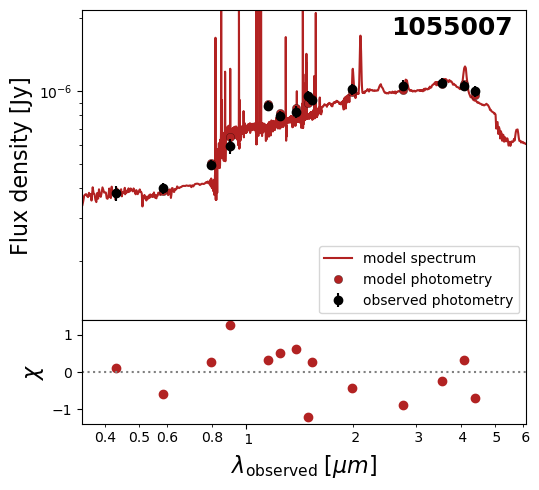

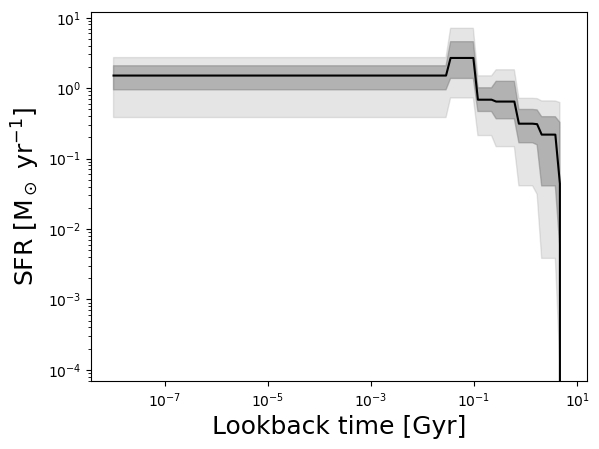

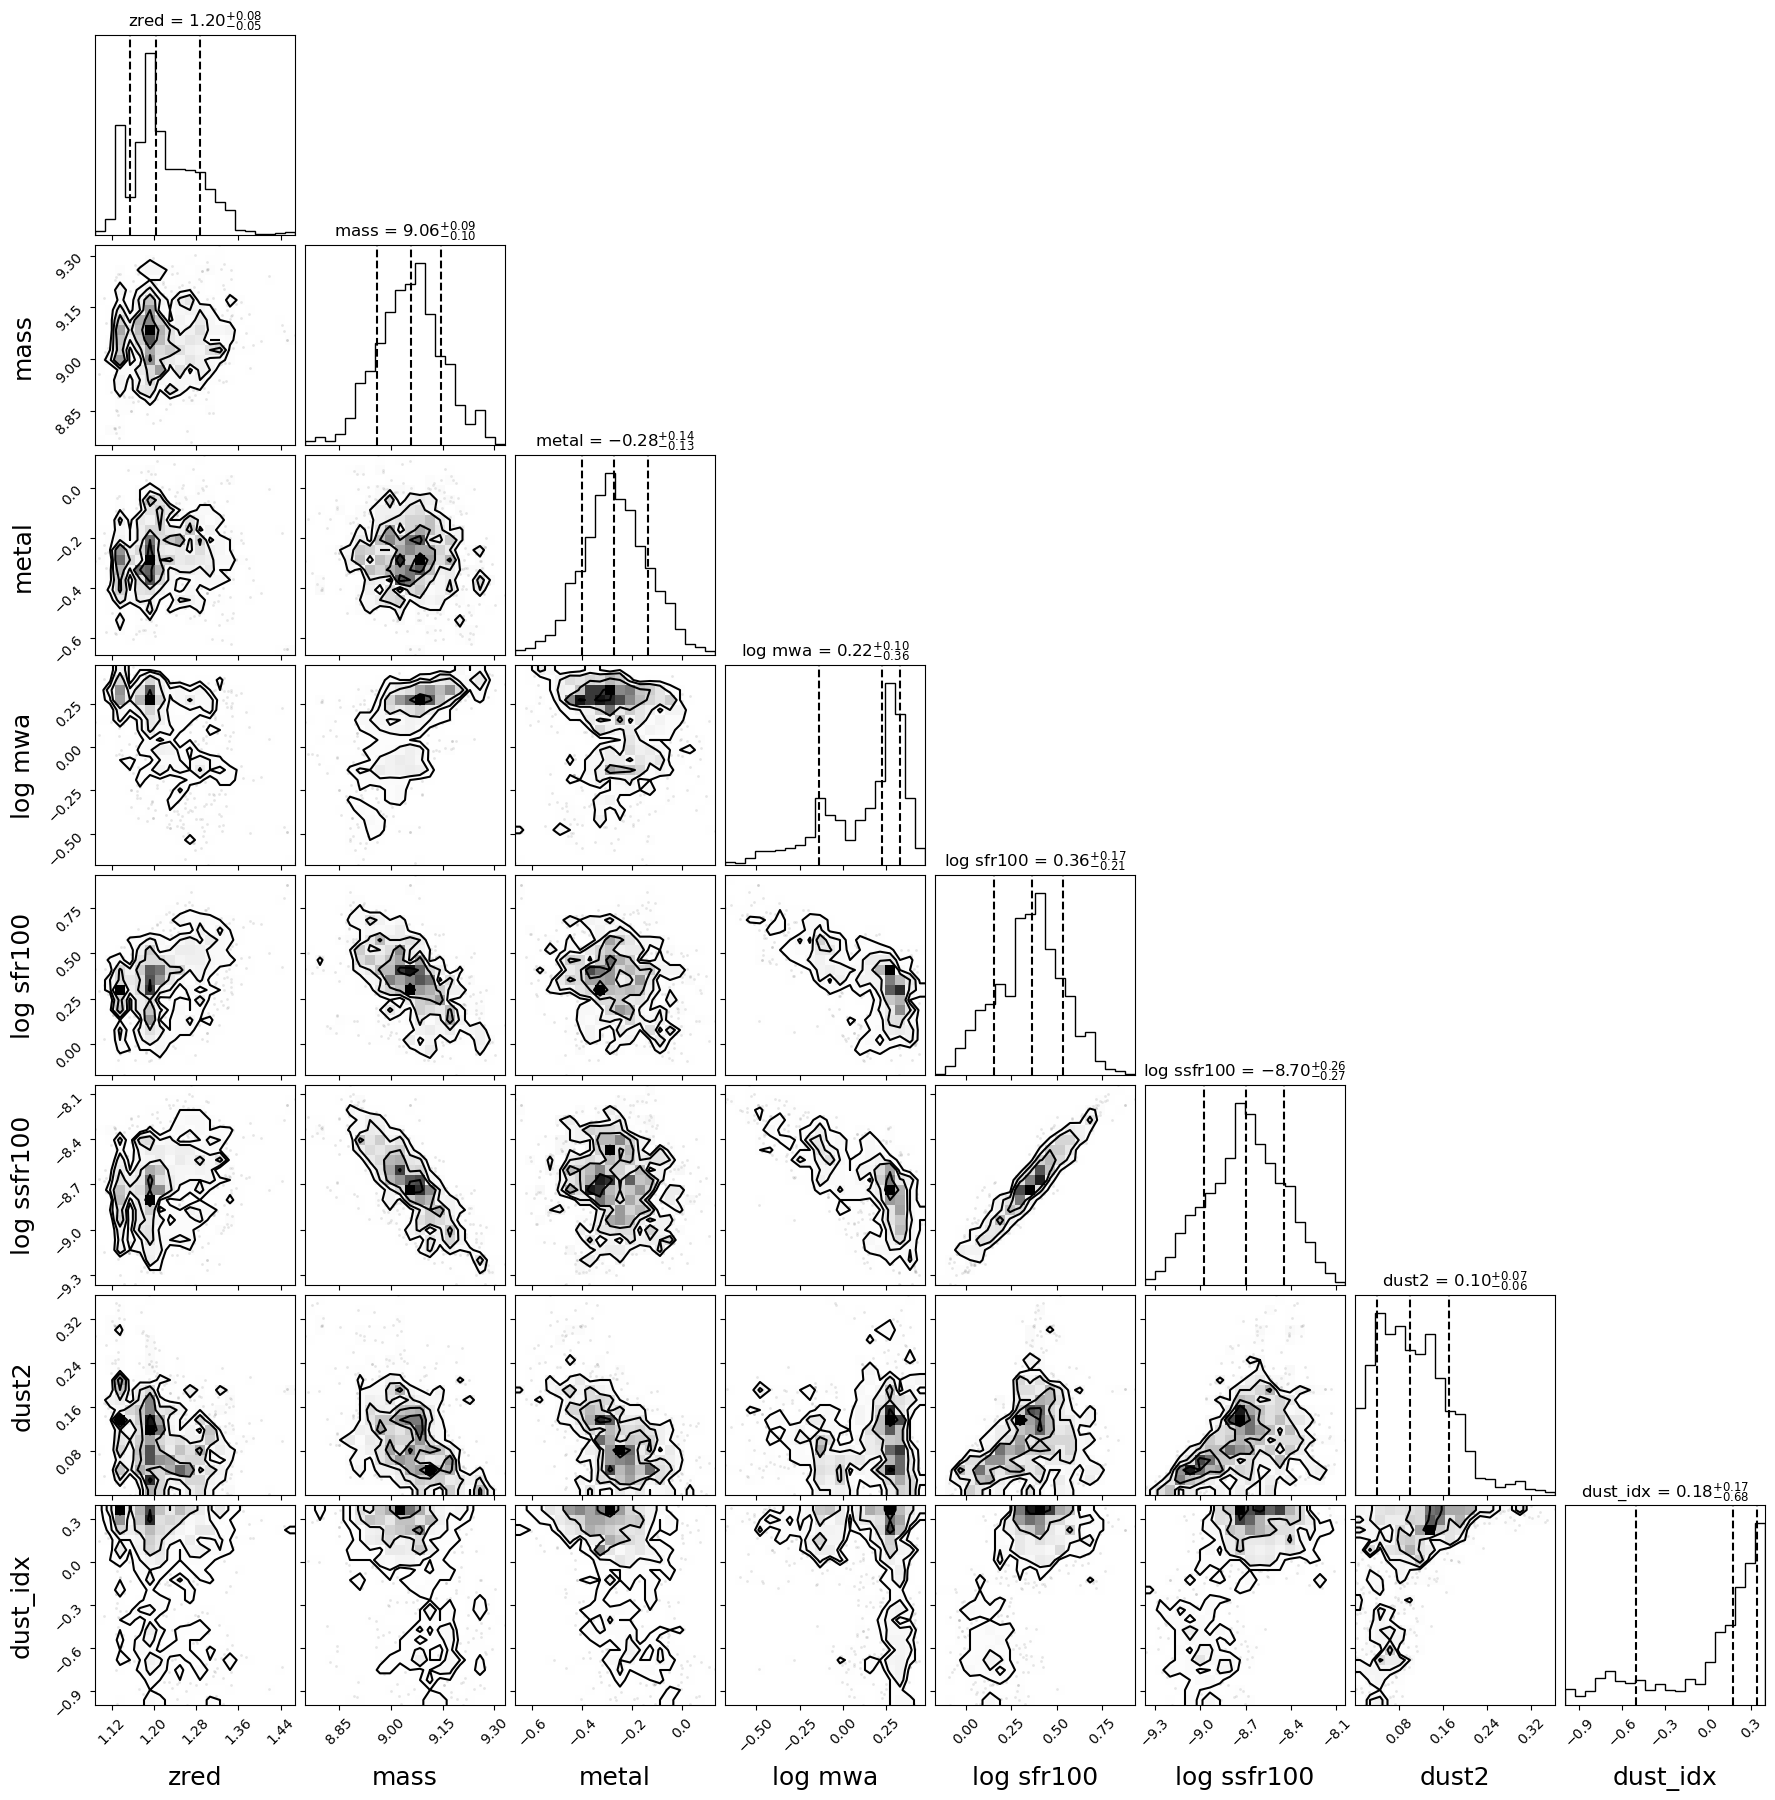

In [26]:
objid = 1055007
sdir = None

plot_sed(objid, sdir=sdir)
plot_sfh(objid, sdir=sdir)
plot_chains(objid, sdir=sdir)